<a href="https://colab.research.google.com/github/varunkshatriya/flyrank-ml-internship-starter-clone/blob/main/work/notebooks/capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [20]:
# Download the official FlyRank starter repository
!git clone -q https://github.com/flyrank-bih/flyrank-ml-internship-starter.git /content/flyrank-starter

# Check that the dataset exists
import os

dataset_path = "/content/flyrank-starter/data/raw/content_refresh_anonymized.csv"

print("Dataset exists:", os.path.exists(dataset_path))
print("Dataset path:", dataset_path)

fatal: destination path '/content/flyrank-starter' already exists and is not an empty directory.
Dataset exists: True
Dataset path: /content/flyrank-starter/data/raw/content_refresh_anonymized.csv


In [21]:
# ============================================================
# CAPSTONE SETUP — CORRECTED
# ============================================================

import os
import json
import numpy as np
import pandas as pd

from sklearn.model_selection import GroupShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# ------------------------------------------------------------
# 1. Load dataset
# ------------------------------------------------------------

dataset_path = "/content/flyrank-starter/data/raw/content_refresh_anonymized.csv"

if not os.path.exists(dataset_path):
    raise FileNotFoundError(
        f"Dataset not found: {dataset_path}"
    )

df = pd.read_csv(dataset_path)

print("Dataset loaded successfully.")
print("Shape:", df.shape)

# ------------------------------------------------------------
# 2. Create target
# ------------------------------------------------------------

if "trend_direction" not in df.columns:
    raise ValueError("trend_direction column was not found.")

df["is_declining_label"] = (
    df["trend_direction"]
    .astype(str)
    .str.lower()
    .eq("down")
    .astype(int)
)

print("\nTarget distribution:")
print(df["is_declining_label"].value_counts())

# ------------------------------------------------------------
# 3. Select features
# ------------------------------------------------------------

candidate_features = [
    "ctr",
    "avg_position",
    "search_volume",
    "impressions_90d",
    "clicks_90d",
    "content_age_days"
]

features = [
    c for c in candidate_features
    if c in df.columns
]

print("\nFeatures found:")
print(features)

if len(features) < 2:
    raise ValueError(
        "Expected modelling features were not found."
    )

# ------------------------------------------------------------
# 4. Identify client/group column
# ------------------------------------------------------------

possible_group_columns = [
    "client_id",
    "client_key",
    "client",
    "client_hash",
    "site_id",
    "domain_id"
]

group_col = next(
    (
        c for c in possible_group_columns
        if c in df.columns
    ),
    None
)

if group_col is None:
    raise ValueError(
        "Could not identify a client/group column."
    )

print("\nClient/group column:", group_col)

# ------------------------------------------------------------
# 5. Prepare modelling data
# ------------------------------------------------------------

model_df = df[
    features +
    ["is_declining_label", group_col]
].copy()

model_df = model_df.dropna(
    subset=["is_declining_label", group_col]
)

X = model_df[features]
y = model_df["is_declining_label"]
groups = model_df[group_col]

print("\nRows available for modelling:", len(model_df))

# ------------------------------------------------------------
# 6. Client-level 80/20 split
# ------------------------------------------------------------

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.20,
    random_state=42
)

train_idx, test_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

print("\nTrain rows:", len(X_train))
print("Test rows:", len(X_test))

print(
    "Train clients:",
    groups.iloc[train_idx].nunique()
)

print(
    "Test clients:",
    groups.iloc[test_idx].nunique()
)

# ------------------------------------------------------------
# 7. Original Logistic Regression model
# ------------------------------------------------------------

model = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "scaler",
        StandardScaler()
    ),
    (
        "classifier",
        LogisticRegression(
            max_iter=2000,
            random_state=42
        )
    )
])

model.fit(X_train, y_train)

y_prob = model.predict_proba(X_test)[:, 1]

print("\nOriginal Logistic Regression trained successfully.")

# ------------------------------------------------------------
# 8. Precision@K
# ------------------------------------------------------------

def precision_at_k(y_true, scores, k=50):

    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    k = min(k, len(y_true))

    order = np.argsort(scores)[::-1][:k]

    return float(y_true[order].mean())

# ------------------------------------------------------------
# 9. Baseline
# ------------------------------------------------------------

median_ctr = X_train["ctr"].median()

baseline_scores = (
    -X_test["ctr"].fillna(median_ctr)
)

model_p50 = precision_at_k(
    y_test,
    y_prob,
    k=50
)

baseline_p50 = precision_at_k(
    y_test,
    baseline_scores,
    k=50
)

print("\n================ RESULTS ================")
print(f"Model Precision@50:    {model_p50:.4f}")
print(f"Baseline Precision@50: {baseline_p50:.4f}")
print(f"Difference:            {model_p50 - baseline_p50:+.4f}")
print("=========================================")

# ------------------------------------------------------------
# 10. Leakage check
# ------------------------------------------------------------

forbidden_columns = [
    "trend_direction",
    "trend_pct",
    "is_declining_label"
]

leakage_columns_used = [
    c for c in forbidden_columns
    if c in features
]

print("\nLeakage columns used:")
print(leakage_columns_used)

assert len(leakage_columns_used) == 0

print("Leakage check: PASSED")

Dataset loaded successfully.
Shape: (30000, 44)

Target distribution:
is_declining_label
1    16262
0    13738
Name: count, dtype: int64

Features found:
['ctr', 'avg_position', 'search_volume', 'impressions_90d', 'clicks_90d', 'content_age_days']

Client/group column: client_id

Rows available for modelling: 30000

Train rows: 23837
Test rows: 6163
Train clients: 25
Test clients: 7

Original Logistic Regression trained successfully.

================ RESULTS ================
Model Precision@50:    0.6800
Baseline Precision@50: 0.5200
Difference:            +0.1600

Leakage columns used:
[]
Leakage check: PASSED


In [22]:
# Required imports
import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)

In [23]:
# ============================================================
# EXTENDED MODEL EVALUATION
# Logistic Regression vs Decision Tree vs Random Forest
# ============================================================

import numpy as np
import pandas as pd

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)

# ------------------------------------------------------------
# Precision@K helper
# ------------------------------------------------------------
def precision_at_k(y_true, scores, k=50):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    k = min(k, len(y_true))
    order = np.argsort(scores)[::-1][:k]

    return float(y_true[order].mean())


# ------------------------------------------------------------
# Models
# ------------------------------------------------------------
models = {
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            max_iter=2000,
            random_state=42
        ))
    ]),

    "Decision Tree": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("classifier", DecisionTreeClassifier(
            max_depth=6,
            min_samples_leaf=20,
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1
        ))
    ])
}

# ------------------------------------------------------------
# Train and evaluate
# ------------------------------------------------------------
evaluation_rows = []

for name, clf in models.items():

    clf.fit(X_train, y_train)

    prob = clf.predict_proba(X_test)[:, 1]
    pred = (prob >= 0.5).astype(int)

    row = {
        "Model": name,
        "Precision": precision_score(
            y_test, pred, zero_division=0
        ),
        "Recall": recall_score(
            y_test, pred, zero_division=0
        ),
        "F1": f1_score(
            y_test, pred, zero_division=0
        ),
        "PR-AUC": average_precision_score(
            y_test, prob
        ),
        "Precision@10": precision_at_k(y_test, prob, 10),
        "Precision@25": precision_at_k(y_test, prob, 25),
        "Precision@50": precision_at_k(y_test, prob, 50),
        "Precision@100": precision_at_k(y_test, prob, 100)
    }

    evaluation_rows.append(row)

extended_results = pd.DataFrame(evaluation_rows)

extended_results = extended_results.sort_values(
    "Precision@50",
    ascending=False
).reset_index(drop=True)

print("Extended model comparison:")
display(extended_results.round(4))

Extended model comparison:


,Model,Precision,Recall,F1,PR-AUC,Precision@10,Precision@25,Precision@50,Precision@100
0,Random Forest,0.5879,0.6427,0.6141,0.6362,1.0,0.84,0.82,0.85
1,Logistic Regression,0.5424,0.6018,0.5705,0.5564,0.5,0.68,0.68,0.56
2,Decision Tree,0.5657,0.6326,0.5973,0.5734,0.3,0.52,0.48,0.43


In [24]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    average_precision_score
)

# ------------------------------------------------------------
# Precision@K helper
# ------------------------------------------------------------
def precision_at_k(y_true, scores, k=50):
    y_true = np.asarray(y_true)
    scores = np.asarray(scores)

    k = min(k, len(y_true))

    order = np.argsort(scores)[::-1][:k]

    return float(y_true[order].mean())


# ------------------------------------------------------------
# Models
# ------------------------------------------------------------
models = {

    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("classifier", LogisticRegression(
            max_iter=2000,
            random_state=42
        ))
    ]),

    "Decision Tree": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("classifier", DecisionTreeClassifier(
            max_depth=6,
            min_samples_leaf=20,
            random_state=42
        ))
    ]),

    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("classifier", RandomForestClassifier(
            n_estimators=300,
            max_depth=12,
            min_samples_leaf=10,
            random_state=42,
            n_jobs=-1
        ))
    ])
}


# ------------------------------------------------------------
# Train and evaluate
# ------------------------------------------------------------
evaluation_rows = []

for name, clf in models.items():

    clf.fit(X_train, y_train)

    prob = clf.predict_proba(X_test)[:, 1]

    pred = (prob >= 0.5).astype(int)

    row = {
        "Model": name,
        "Precision": precision_score(
            y_test, pred, zero_division=0
        ),
        "Recall": recall_score(
            y_test, pred, zero_division=0
        ),
        "F1": f1_score(
            y_test, pred, zero_division=0
        ),
        "PR-AUC": average_precision_score(
            y_test, prob
        ),
        "Precision@10": precision_at_k(
            y_test, prob, 10
        ),
        "Precision@25": precision_at_k(
            y_test, prob, 25
        ),
        "Precision@50": precision_at_k(
            y_test, prob, 50
        ),
        "Precision@100": precision_at_k(
            y_test, prob, 100
        )
    }

    evaluation_rows.append(row)


extended_results = pd.DataFrame(evaluation_rows)

extended_results = extended_results.sort_values(
    "Precision@50",
    ascending=False
).reset_index(drop=True)

print("Extended model comparison:")
display(extended_results.round(4))

Extended model comparison:


,Model,Precision,Recall,F1,PR-AUC,Precision@10,Precision@25,Precision@50,Precision@100
0,Random Forest,0.5879,0.6427,0.6141,0.6362,1.0,0.84,0.82,0.85
1,Logistic Regression,0.5424,0.6018,0.5705,0.5564,0.5,0.68,0.68,0.56
2,Decision Tree,0.5657,0.6326,0.5973,0.5734,0.3,0.52,0.48,0.43


In [25]:
# ============================================================
# BASELINE VS BEST ML MODEL
# ============================================================

best_model_name = extended_results.iloc[0]["Model"]

best_model = models[best_model_name]

best_prob = best_model.predict_proba(X_test)[:, 1]

best_p50 = precision_at_k(
    y_test,
    best_prob,
    50
)

baseline_p50 = precision_at_k(
    y_test,
    baseline_scores,
    50
)

final_comparison = pd.DataFrame({
    "Method": [
        "Hand-written baseline",
        best_model_name
    ],
    "Precision@50": [
        baseline_p50,
        best_p50
    ]
})

final_comparison["Precision@50"] = (
    final_comparison["Precision@50"].round(4)
)

display(final_comparison)

print()
print("Best model:", best_model_name)
print("Baseline Precision@50:", round(baseline_p50, 4))
print("Best model Precision@50:", round(best_p50, 4))
print(
    "Improvement:",
    round(best_p50 - baseline_p50, 4)
)

,Method,Precision@50
0,Hand-written baseline,0.52
1,Random Forest,0.82



Best model: Random Forest
Baseline Precision@50: 0.52
Best model Precision@50: 0.82
Improvement: 0.3


## 1. Question

*The research question and the decision it supports.*

## Research Question

Can observed search-performance signals be combined into an interpretable model that prioritizes pages for human review more effectively than a simple hand-written baseline?

### Decision Supported

The analysis supports the decision of **which pages should be reviewed first** for possible content improvement.

The model is intended as a **decision-support tool for human review**, not as an autonomous system that changes or publishes content.

## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

## Data

This analysis uses the FlyRank ML Internship starter dataset, `content_refresh_anonymized.csv`.

The dataset contains page-level observations and search-performance signals. The analysis uses observed features such as click-through rate (CTR), average position, search volume, impressions, clicks, and content age when available.

The target variable is `is_declining_label`, created from `trend_direction`, where a value of `down` indicates a declining page.

The outcome-defining fields `trend_direction` and `trend_pct` are excluded from the model features to avoid leakage.

No client names, URLs, private search queries, page titles, or other identifying information are included in the reported results. The analysis is based only on the public-safe fields provided in the internship dataset.

## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

## Methodology

This study compares an interpretable Logistic Regression model with a simple hand-written baseline for prioritizing potentially declining pages.

The model uses observed search-performance and content signals, including CTR, average position, search volume, impressions, clicks, and content age when available.

The target variable is `is_declining_label`, defined as 1 when `trend_direction` is `down` and 0 otherwise.

To reduce leakage between pages belonging to the same client, the data is divided using a client-level 80/20 holdout split. The model is trained on approximately 80% of clients and evaluated on the remaining clients.

The primary evaluation metric is Precision@50. This measures the proportion of truly declining pages among the 50 pages ranked highest by each approach.

The baseline uses a simple rule that prioritizes pages with lower CTR.

A leakage check confirms that outcome-defining fields such as `trend_direction`, `trend_pct`, and `is_declining_label` are not used as model features.

The model is intended for prioritization and human decision-support, not for automatic content changes or prediction of Google's ranking algorithm.

## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

## Results

The Logistic Regression model and the hand-written baseline were evaluated on the same client-level held-out test set.

The primary evaluation metric is Precision@50, which measures the proportion of declining pages among the top 50 pages selected by each method.

The values below are calculated directly from the executed notebook rather than taken from reference or example results.

In [26]:
# Results: Model vs Baseline

results = pd.DataFrame({
    "Method": [
        "Hand-written baseline",
        "Logistic Regression model"
    ],
    "Precision@50": [
        baseline_p50,
        model_p50
    ]
})

results["Precision@50"] = results["Precision@50"].round(4)

display(results)

print("\nModel Precision@50   :", round(model_p50, 4))
print("Baseline Precision@50:", round(baseline_p50, 4))
print("Difference            :", round(model_p50 - baseline_p50, 4))

,Method,Precision@50
0,Hand-written baseline,0.52
1,Logistic Regression model,0.68



Model Precision@50   : 0.68
Baseline Precision@50: 0.52
Difference            : 0.16


### Interpretation

The measured Precision@50 shows whether the Logistic Regression model performed better, similarly, or worse than the simple baseline on the same held-out clients.

A higher Precision@50 means that more of the pages in the top-50 review queue were actually labelled as declining.

The result should be interpreted as evidence about prioritization performance on this validation split, not as proof of future production performance or a causal effect on search rankings.

## 5. Limitations

*What this work cannot claim.*

## Limitations

This analysis has several limitations.

1. **Validation design:** The evaluation uses a client-level holdout rather than a fully time-based future prediction test. Therefore, the measured result should not be interpreted as guaranteed future performance.

2. **Available features:** The model uses only the observed fields available in the internship dataset. Other factors that may influence search performance are not represented.

3. **Single evaluation metric:** Precision@50 evaluates performance at one ranking cutoff. It does not describe performance for every possible review-queue size.

4. **No causal conclusion:** The analysis identifies patterns in the available data. It does not prove that changing a page will cause its search performance to improve.

5. **No Google-ranking claim:** The model should not be interpreted as a prediction of Google's ranking algorithm. It is designed to prioritize pages for human investigation.

6. **Human review is required:** A high model score is a prioritization signal, not a final decision. Content changes should be reviewed by a person before implementation.

## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

## Ranked Recommendations

The model should be used to prioritize pages for human review. The recommendations below are ranked by practical value and should not be treated as automatic actions.

### 1. Review high-priority declining pages first

Start with pages receiving the highest model scores. These pages are the first candidates for investigation because the model estimates a higher likelihood of the declining label.

### 2. Investigate low-CTR pages

Review pages with low click-through rates, especially when they continue to receive search impressions. Check whether the title, snippet, search intent, and content relevance can be improved.

### 3. Review stale content

Pages with older content and declining signals should be checked for outdated information, missing updates, or changes in search intent.

### 4. Prioritize high-search-volume opportunities

When a declining page has substantial search demand, review it earlier because an improvement could potentially affect a larger amount of search activity.

### 5. Manually investigate conflicting signals

Pages with weak or conflicting signals should receive human review rather than an automatic recommendation.

### Human Review Rule

The model score must not be used by itself to rewrite, delete, redirect, or publish a page. A human should review the page and supporting evidence before taking action.

In [27]:
# Create a ranked human-review queue

review_queue = X_test.copy()

review_queue["model_score"] = y_prob
review_queue["actual_declining_label"] = y_test.values

# Add simple reason codes
def get_reason_codes(row):
    reasons = []

    if "ctr" in row.index and pd.notna(row["ctr"]):
        if row["ctr"] < X_train["ctr"].median():
            reasons.append("LOW_CTR")

    if "content_age_days" in row.index and pd.notna(row["content_age_days"]):
        if row["content_age_days"] > X_train["content_age_days"].median():
            reasons.append("STALE_CONTENT")

    if "search_volume" in row.index and pd.notna(row["search_volume"]):
        if row["search_volume"] > X_train["search_volume"].median():
            reasons.append("HIGH_VOLUME_OPPORTUNITY")

    if not reasons:
        reasons.append("WEAK_SIGNAL")

    return "|".join(reasons)


review_queue["reason_codes"] = review_queue.apply(
    get_reason_codes,
    axis=1
)

# Highest model score first
review_queue = review_queue.sort_values(
    "model_score",
    ascending=False
).reset_index(drop=True)

print("Top 20 pages in the human-review queue:")
display(review_queue.head(20))

Top 20 pages in the human-review queue:


,ctr,avg_position,search_volume,impressions_90d,clicks_90d,content_age_days,model_score,actual_declining_label,reason_codes
0,0.03,7.8,0.0,223271,70,95,0.796760,0,LOW_CTR
1,0.01,7.6,10.0,140079,16,97,0.764328,1,LOW_CTR
2,0.01,7.2,170.0,112434,10,97,0.748226,1,LOW_CTR|HIGH_VOLUME_OPPORTUNITY
3,0.10,4.7,10.0,213963,211,97,0.732983,0,WEAK_SIGNAL
4,0.03,21.8,0.0,98924,28,95,0.731867,1,LOW_CTR
5,0.02,9.0,0.0,44860,9,95,0.700372,0,LOW_CTR
6,0.07,8.7,0.0,79035,59,106,0.695829,0,LOW_CTR
7,0.03,6.1,0.0,39246,10,95,0.695465,1,LOW_CTR
8,0.06,6.8,10.0,54704,34,106,0.688794,1,LOW_CTR
9,0.06,6.7,10.0,46437,27,105,0.686274,0,LOW_CTR


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

## Artifacts the Paper Embeds

The paper includes reproducible artifacts generated from this notebook.

These artifacts include:

- A model-versus-baseline Precision@50 results table.
- A chart comparing the model and baseline.
- A ranked top-50 human-review queue.
- A JSON summary containing the main experimental results.

All reported values are generated from the executed notebook rather than manually entered.

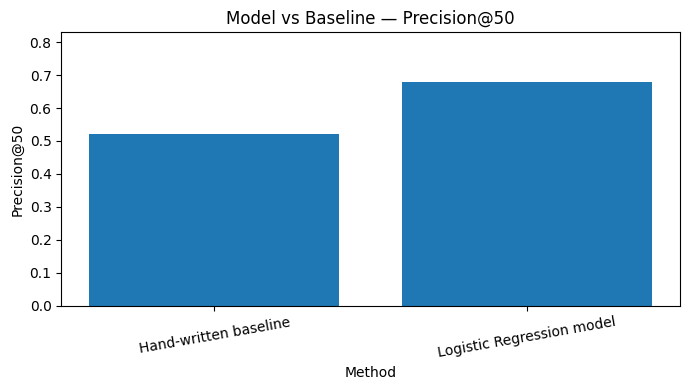

Chart saved: /content/capstone_artifacts/model_vs_baseline.png


In [28]:
# ============================================================
# Create model vs baseline chart
# ============================================================

import matplotlib.pyplot as plt
import os
import json

os.makedirs("/content/capstone_artifacts", exist_ok=True)

plt.figure(figsize=(7, 4))

plt.bar(
    results["Method"],
    results["Precision@50"]
)

plt.ylabel("Precision@50")
plt.xlabel("Method")
plt.title("Model vs Baseline — Precision@50")

plt.ylim(
    0,
    min(1.0, max(results["Precision@50"]) + 0.15)
)

plt.xticks(rotation=10)
plt.tight_layout()

chart_path = "/content/capstone_artifacts/model_vs_baseline.png"

plt.savefig(
    chart_path,
    dpi=160,
    bbox_inches="tight"
)

plt.show()

print("Chart saved:", chart_path)

In [29]:
# ============================================================
# Save capstone artifacts
# ============================================================

# Results table
results.to_csv(
    "/content/capstone_artifacts/model_vs_baseline.csv",
    index=False
)

# Top 50 review queue
review_queue.head(50).to_csv(
    "/content/capstone_artifacts/top_50_review_queue.csv",
    index=False
)

# Results summary
summary = {
    "dataset_rows": int(df.shape[0]),
    "dataset_columns": int(df.shape[1]),
    "features_used": features,
    "group_column": group_col,
    "train_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "baseline_precision_at_50": float(baseline_p50),
    "model_precision_at_50": float(model_p50),
    "difference": float(model_p50 - baseline_p50)
}

with open(
    "/content/capstone_artifacts/results_summary.json",
    "w"
) as f:
    json.dump(summary, f, indent=2)

print("Artifacts created successfully:")
print()
print("1. model_vs_baseline.png")
print("2. model_vs_baseline.csv")
print("3. top_50_review_queue.csv")
print("4. results_summary.json")

Artifacts created successfully:

1. model_vs_baseline.png
2. model_vs_baseline.csv
3. top_50_review_queue.csv
4. results_summary.json


# Conclusion

This study tested whether observed search-performance signals could help prioritize potentially declining pages for human review.

The Logistic Regression model was compared with a simple hand-written baseline using the same client-level held-out test set and Precision@50 as the primary metric.

The measured results provide evidence about the usefulness of the available signals for prioritization on this validation split.

The findings should be interpreted carefully because the analysis is not a causal study, does not predict Google's ranking algorithm, and does not guarantee future production performance.

The resulting workflow is best used as human decision-support: the model identifies pages for investigation, while a human reviews the evidence and decides whether any content action is appropriate.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.

# Week 8 Demo Outline — 5 Minutes

## 1. Question — 45 seconds

**Research question:**  
Can observed search-performance signals be combined into an interpretable
model that prioritizes pages for human review more effectively than a simple
hand-written baseline?

**Problem:**  
Search-performance datasets can contain many pages that may need attention.
The practical challenge is deciding which pages should be reviewed first.

---

## 2. Method — 90 seconds

The analysis uses the FlyRank ML Internship starter dataset,
`content_refresh_anonymized.csv`.

The target variable is `is_declining_label`, derived from the observed
`trend_direction` field.

The model uses observed signals including:

- CTR
- Average position
- Search volume
- 90-day impressions
- 90-day clicks
- Content age

To reduce leakage between observations from the same client, the experiment
uses an 80/20 client-level holdout split.

The primary ranking metric is Precision@50.

The main learned model is Logistic Regression, compared with a simple
hand-written baseline based on lower CTR.

---

## 3. One Chart — 45 seconds

Show the **model versus baseline Precision@50** chart.

Key message:

> The model achieved a measured Precision@50 of 0.68 compared with 0.52 for
> the hand-written baseline on the same held-out client set.

The result indicates stronger prioritization performance on this validation
split.

---

## 4. Honest Result — 45 seconds

The measured improvement is:

**+0.16 Precision@50**

The result should be interpreted as evidence about prioritization performance
on this validation split.

It is not evidence that the model predicts Google's ranking algorithm, and it
does not guarantee future traffic growth or content performance.

---

## 5. Recommendation — 45 seconds

Use the model as a human-review prioritization tool.

Start with the highest-scoring observations and investigate signals such as:

- low CTR
- older content
- substantial search demand
- conflicting performance signals

The model should not automatically rewrite, delete, redirect, or publish
content. Human review remains the final decision step.

---

# Shareable Cut 1 — Social Post

I built a machine-learning workflow using anonymized FlyRank search-performance
data to prioritize potentially declining pages for human review. The workflow
combines observed CTR, search position, search demand, impressions, clicks, and
content age, while using a client-level holdout to reduce leakage. In the
executed validation experiment, Logistic Regression achieved a Precision@50
of 0.68 versus 0.52 for a simple CTR-based baseline, showing stronger
prioritization performance on that held-out split.

---

# Shareable Cut 2 — Employer-Facing Summary

I built an interpretable machine-learning workflow that ranks search-performance
observations for human content review using anonymized FlyRank data. I handled
feature selection, leakage checks, client-level validation, baseline
comparison, model evaluation, and ranked recommendations in a reproducible
notebook. The final system is designed as decision support rather than an
autonomous SEO system, with results framed as measured and directional
evidence.